# Trainable Model Diagnostic Study
Three model families trained on the EHS video dataset. Produces figures usable in a white paper.


In [1]:
# ── 0. Setup ───────────────────────────────────────────────────────────────────────────────
# Put this in MyDrive/capstone/ before running:
#   data/dataset_mapping.xlsx
#   data/videos/               ← VID*** folders
#   few_shot_diagnostic/scripts/
import subprocess, sys, os, shutil

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm", "umap-learn", "grad-cam", "openpyxl", "opencv-python-headless"],
               check=True)

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/capstone"
LOCAL_ROOT = "/content/capstone"

for folder in ["data", "few_shot_diagnostic"]:
    src = os.path.join(DRIVE_ROOT, folder)
    dst = os.path.join(LOCAL_ROOT, folder)
    if not os.path.isdir(dst):
        print(f"Copying {folder}/ ...")
        shutil.copytree(src, dst)
    else:
        print(f"{folder}/ already local — skipping.")

SCRIPTS_DIR = f"{LOCAL_ROOT}/few_shot_diagnostic/scripts"
DATA_EXCEL  = f"{LOCAL_ROOT}/data/dataset_mapping.xlsx"
VIDEOS_DIR  = f"{LOCAL_ROOT}/data/videos"
OUTPUTS_DIR = "/content/few_shot_outputs"
os.makedirs(OUTPUTS_DIR, exist_ok=True)

for p in [LOCAL_ROOT, SCRIPTS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

os.chdir(LOCAL_ROOT)

import torch
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
N_FOLDS     = 5
N_EPOCHS    = 50
LOG_EVERY   = 5
PATIENCE    = 3
BATCH_SIZE  = 16
N_FRAMES    = 16
SEED        = 42

torch.manual_seed(SEED)
print(f"DATA_EXCEL: {DATA_EXCEL}  exists={os.path.exists(DATA_EXCEL)}")
print(f"VIDEOS_DIR: {VIDEOS_DIR}  exists={os.path.isdir(VIDEOS_DIR)}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Copying data/ ...
Copying few_shot_diagnostic/ ...
DATA_EXCEL: /content/capstone/data/dataset_mapping.xlsx  exists=True
VIDEOS_DIR: /content/capstone/data/videos  exists=True
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


---
## 1. Dataset

Originals: 73  |  Augmented: 730  |  Total: 803
Binary   — Accident: 43  No Accident: 30


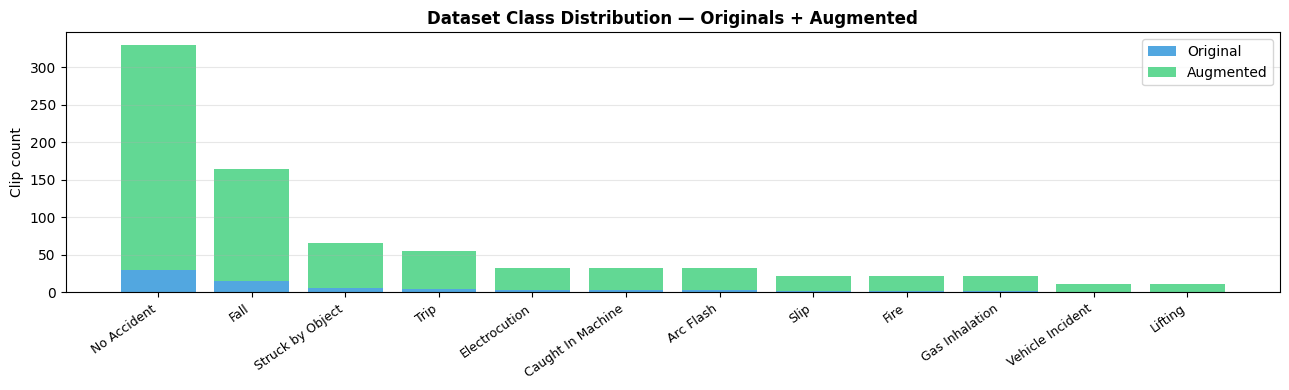

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from dataset import (
    load_ground_truth, MERGED_CATEGORIES,
    extract_base_vid, build_aug_labels, compute_class_weights, get_transform,
)

def find_local_videos(root_dir, originals_only=True):
    """Walk data/videos/ and return sorted .mp4 paths."""
    import glob, os as _os
    root = _os.path.abspath(root_dir)
    if originals_only:
        return sorted(glob.glob(_os.path.join(root, "*", "original.mp4")))
    paths = []
    for vid_folder in sorted(_os.listdir(root)):
        vp = _os.path.join(root, vid_folder)
        if not _os.path.isdir(vp): continue
        orig = _os.path.join(vp, "original.mp4")
        if _os.path.isfile(orig): paths.append(orig)
        for sub in sorted(_os.listdir(vp)):
            sp = _os.path.join(vp, sub)
            if _os.path.isdir(sp):
                for f in sorted(_os.listdir(sp)):
                    if f.lower().endswith(".mp4"): paths.append(_os.path.join(sp, f))
    return sorted(paths)

# ── Ground truth ──────────────────────────────────────────────────────────────
gt = load_ground_truth(DATA_EXCEL)
vid_to_binary   = dict(zip(gt["video_id_clean"], gt["true_binary"]))
vid_to_category = dict(zip(gt["video_id_clean"], gt["true_category"]))

# Class lists
BINARY_CLASSES = ["No Accident", "Accident"]
MULTI_CLASSES  = ["No Accident"] + MERGED_CATEGORIES

bin_to_idx  = {c: i for i, c in enumerate(BINARY_CLASSES)}
multi_to_idx = {c: i for i, c in enumerate(MULTI_CLASSES)}

# ── Video paths ───────────────────────────────────────────────────────────────
orig_paths = find_local_videos(VIDEOS_DIR, originals_only=True)
all_paths  = find_local_videos(VIDEOS_DIR, originals_only=False)
aug_paths  = [p for p in all_paths if p not in set(orig_paths)]

# Map paths → labels
def path_to_labels(path):
    vid = extract_base_vid(path)
    binary   = bin_to_idx.get(vid_to_binary.get(vid, "No Accident"), 0)
    category = multi_to_idx.get(vid_to_category.get(vid, "No Accident"), 0)
    return binary, category

orig_bin_labels  = [path_to_labels(p)[0] for p in orig_paths]
orig_multi_labels = [path_to_labels(p)[1] for p in orig_paths]
aug_bin_labels   = [path_to_labels(p)[0] for p in aug_paths]
aug_multi_labels = [path_to_labels(p)[1] for p in aug_paths]

vid_to_bin_idx = {extract_base_vid(p): path_to_labels(p)[0] for p in orig_paths}

print(f"Originals: {len(orig_paths)}  |  Augmented: {len(aug_paths)}  |  Total: {len(orig_paths)+len(aug_paths)}")
print(f"Binary   — Accident: {sum(orig_bin_labels)}  No Accident: {orig_bin_labels.count(0)}")

# ── Class distribution chart ──────────────────────────────────────────────────
from collections import Counter
cat_counts = Counter(vid_to_category.values())
aug_counts = Counter(vid_to_category[extract_base_vid(p)] for p in aug_paths)

cats   = sorted(cat_counts, key=cat_counts.get, reverse=True)
orig_c = [cat_counts[c] for c in cats]
aug_c  = [aug_counts.get(c, 0) for c in cats]

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(cats))
ax.bar(x, orig_c, label="Original", color="#3498db", alpha=0.85)
ax.bar(x, aug_c,  label="Augmented", color="#2ecc71", alpha=0.75, bottom=orig_c)
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Clip count"); ax.legend(); ax.grid(True, axis="y", alpha=0.3)
ax.set_title("Dataset Class Distribution — Originals + Augmented", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Cross-Validation Setup

In [3]:
from dataset import make_splits

# Binary splits
binary_folds = make_splits(orig_paths, orig_bin_labels, aug_paths, aug_bin_labels, N_FOLDS, SEED)
# Multiclass splits (same fold structure, different labels)
multi_folds  = make_splits(orig_paths, orig_multi_labels, aug_paths, aug_multi_labels, N_FOLDS, SEED)

print(f"{'Fold':<6} {'Train (orig+aug)':<20} {'Val (orig only)':<18} {'Val class dist'}")
print("─" * 65)
for i, (tr_p, tr_l, vl_p, vl_l) in enumerate(binary_folds):
    val_acc  = sum(1 for l in vl_l if l == 1)
    val_noac = sum(1 for l in vl_l if l == 0)
    print(f"  {i+1}    {len(tr_p):<20} {len(vl_p):<18} Acc={val_acc}  NoAcc={val_noac}")

# Class weights (computed on training labels from fold 0 as representative)
bin_weights   = compute_class_weights(binary_folds[0][1],  n_classes=len(BINARY_CLASSES))
multi_weights = compute_class_weights(multi_folds[0][1],   n_classes=len(MULTI_CLASSES))
print(f"\nBinary class weights: {bin_weights.tolist()}")


Fold   Train (orig+aug)     Val (orig only)    Val class dist
─────────────────────────────────────────────────────────────────
  1    638                  15                 Acc=9  NoAcc=6
  2    638                  15                 Acc=9  NoAcc=6
  3    638                  15                 Acc=9  NoAcc=6
  4    649                  14                 Acc=8  NoAcc=6
  5    649                  14                 Acc=8  NoAcc=6

Binary class weights: [1.2083333730697632, 0.8529412150382996]


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [4]:
from dataset import preload_frames

# Pre-extract all frames into RAM (~1-2 GB; eliminates cv2 seeks during training)
print("Preloading frames into RAM...")
all_vid_paths = list(set(orig_paths + aug_paths))
FRAME_CACHE = preload_frames(all_vid_paths, N_FRAMES)
print(f"Cache size: {len(FRAME_CACHE)} videos")

Preloading frames into RAM...
  preloaded 25/803
  preloaded 50/803
  preloaded 75/803
  preloaded 100/803
  preloaded 125/803
  preloaded 150/803
  preloaded 175/803
  preloaded 200/803
  preloaded 225/803
  preloaded 250/803
  preloaded 275/803
  preloaded 300/803
  preloaded 325/803
  preloaded 350/803
  preloaded 375/803
  preloaded 400/803
  preloaded 425/803
  preloaded 450/803
  preloaded 475/803
  preloaded 500/803
  preloaded 525/803
  preloaded 550/803
  preloaded 575/803
  preloaded 600/803
  preloaded 625/803
  preloaded 650/803
  preloaded 675/803
  preloaded 700/803
  preloaded 725/803
  preloaded 750/803
  preloaded 775/803
  preloaded 800/803
  preloaded 803/803 — done
Cache size: 803 videos


---
## 3. Train FrameCNN (Spatial Baseline)

In [5]:
from torch.utils.data import DataLoader
from dataset import VideoDataset, get_transform
from models import build_model
from train import train_model, attach_criterion
from evaluate import evaluate_fold, summarise_cv, print_summary, best_fold

def run_cv(model_name, folds, class_names, class_weights, n_frames=N_FRAMES, frame_cache=None):
    model_type = "cnn3d" if model_name == "cnn3d" else "lrcn"
    task = "multi" if len(class_names) > 2 else "binary"
    fold_results, histories = [], []
    for fold_idx, (tr_p, tr_l, vl_p, vl_l) in enumerate(folds):
        print(f"\n  ── Fold {fold_idx+1}/{len(folds)} ──")
        tr_ds = VideoDataset(tr_p, tr_l, n_frames, get_transform("train"), model_type, frame_cache)
        vl_ds = VideoDataset(vl_p, vl_l, n_frames, get_transform("val"),   model_type, frame_cache)
        tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
        vl_dl = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        model = build_model(model_name, n_classes=len(class_names))
        attach_criterion(model, class_weights.to(DEVICE))

        result = train_model(model, tr_dl, vl_dl,
                             n_epochs=N_EPOCHS, log_every=LOG_EVERY,
                             patience=PATIENCE, device=DEVICE)
        histories.append(result.history)

        fold_eval = evaluate_fold(model, vl_dl, class_names, DEVICE, fold=fold_idx)
        fold_results.append(fold_eval)

        ckpt_path = os.path.join(OUTPUTS_DIR, f"{model_name}_{task}_fold{fold_idx+1}.pt")
        torch.save(result.best_state_dict, ckpt_path)

    return fold_results, histories

print("=" * 60)
print("FrameCNN — Binary")
print("=" * 60)
fc_bin_results, fc_bin_histories = run_cv(
    "framecnn", binary_folds, BINARY_CLASSES, bin_weights, frame_cache=FRAME_CACHE
)
fc_bin_summary = summarise_cv(fc_bin_results, BINARY_CLASSES)
print_summary("FrameCNN Binary", fc_bin_summary)

FrameCNN — Binary

  ── Fold 1/5 ──


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.800)

  ── Fold 2/5 ──


...

  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.733)

  ── Fold 4/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0065  acc=0.997 | val_loss=1.4849  val_acc=0.714  [overfit]
  Early stop at epoch 5 — restoring epoch 2 (val_acc=0.786)

  ── Fold 5/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.643)

────────────────────────────────────────────────────────────
  FrameCNN Binary
────────────────────────────────────────────────────────────
  Binary F1:  0.821 ± 0.066
  Macro  F1:  0.738 ± 0.074


---
## 4. Train LRCN

In [6]:
print("=" * 60)
print("LRCN — Binary")
print("=" * 60)
lrcn_bin_results, lrcn_bin_histories = run_cv(
    "lrcn", binary_folds, BINARY_CLASSES, bin_weights, frame_cache=FRAME_CACHE
)
lrcn_bin_summary = summarise_cv(lrcn_bin_results, BINARY_CLASSES)
print_summary("LRCN Binary", lrcn_bin_summary)

LRCN — Binary

  ── Fold 1/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0884  acc=0.980 | val_loss=1.4714  val_acc=0.733  [overfit]
  Early stop at epoch 5 — restoring epoch 2 (val_acc=0.867)

  ── Fold 2/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.800)

  ── Fold 3/5 ──


...

  Epoch   5 | loss=0.0727  acc=0.976 | val_loss=1.5935  val_acc=0.667
  Early stop at epoch 5 — restoring epoch 2 (val_acc=0.733)

  ── Fold 4/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0917  acc=0.972 | val_loss=2.1299  val_acc=0.714
  Early stop at epoch 7 — restoring epoch 4 (val_acc=0.786)

  ── Fold 5/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0649  acc=0.977 | val_loss=2.3025  val_acc=0.643  [overfit]
  Early stop at epoch 5 — restoring epoch 2 (val_acc=0.714)

────────────────────────────────────────────────────────────
  LRCN Binary
────────────────────────────────────────────────────────────
  Binary F1:  0.817 ± 0.057
  Macro  F1:  0.759 ± 0.068


---
## 5. Train CNN3D (R3D-18, Kinetics-400)

In [7]:
print("=" * 60)
print("CNN3D — Binary")
print("=" * 60)
cnn3d_bin_results, cnn3d_bin_histories = run_cv(
    "cnn3d", binary_folds, BINARY_CLASSES, bin_weights, n_frames=32, frame_cache=FRAME_CACHE
)
cnn3d_bin_summary = summarise_cv(cnn3d_bin_results, BINARY_CLASSES)
print_summary("CNN3D Binary", cnn3d_bin_summary)

CNN3D — Binary

  ── Fold 1/5 ──
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 222MB/s]
/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0226  acc=0.987 | val_loss=0.7184  val_acc=0.867  [overfit]
  Early stop at epoch 6 — restoring epoch 3 (val_acc=0.933)

  ── Fold 2/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0454  acc=0.986 | val_loss=1.2088  val_acc=0.733  [overfit]
  Early stop at epoch 7 — restoring epoch 4 (val_acc=0.867)

  ── Fold 3/5 ──


...

  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.733)

  ── Fold 4/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0291  acc=0.994 | val_loss=0.8777  val_acc=0.857 ← best
  Early stop at epoch 8 — restoring epoch 5 (val_acc=0.857)

  ── Fold 5/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.857)

────────────────────────────────────────────────────────────
  CNN3D Binary
────────────────────────────────────────────────────────────
  Binary F1:  0.862 ± 0.065
  Macro  F1:  0.845 ± 0.063


---
## 6. Results Summary

,Binary F1,Macro F1
Model,,
FrameCNN,0.821 ± 0.066,0.738 ± 0.074
LRCN,0.817 ± 0.057,0.759 ± 0.068
CNN3D,0.862 ± 0.065,0.845 ± 0.063
Δ LRCN − FrameCNN,-0.004,
Δ CNN3D − FrameCNN,+0.041,


Saved → /content/few_shot_outputs/results_summary.png


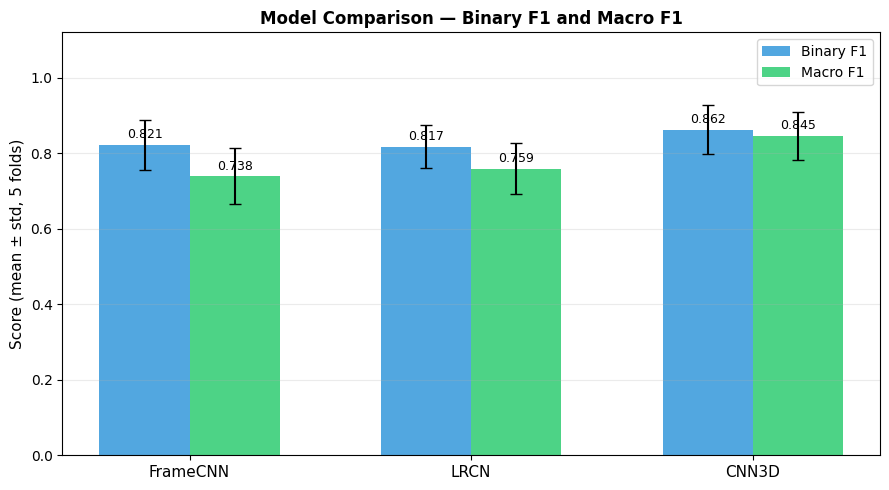

In [8]:
from visualize import plot_results_summary

summaries = {
    "FrameCNN": fc_bin_summary,
    "LRCN":     lrcn_bin_summary,
    "CNN3D":    cnn3d_bin_summary,
}

# Table
rows = []
for name, s in summaries.items():
    rows.append({
        "Model":       name,
        "Binary F1":   f"{s['binary_f1_mean']:.3f} ± {s['binary_f1_std']:.3f}",
        "Macro F1":    f"{s['macro_f1_mean']:.3f} ± {s['macro_f1_std']:.3f}",
    })

# Temporal gain rows
for name in ["LRCN", "CNN3D"]:
    gain = summaries[name]["binary_f1_mean"] - summaries["FrameCNN"]["binary_f1_mean"]
    rows.append({"Model": f"  Δ {name} − FrameCNN", "Binary F1": f"{gain:+.3f}", "Macro F1": ""})

import pandas as pd
df_results = pd.DataFrame(rows).set_index("Model")
display(df_results)
df_results.to_csv(os.path.join(OUTPUTS_DIR, "results_summary.csv"))

# Chart
plot_results_summary(summaries, os.path.join(OUTPUTS_DIR, "results_summary.png"))


---
## 7. Per-Class F1 Heatmap

*Runs multiclass task on best binary model weights for each architecture.*

Running multiclass CV for per-class F1 analysis...

  ── Fold 1/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.333)

  ── Fold 2/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.400)

  ── Fold 3/5 ──


...

  Early stop at epoch 4 — restoring epoch 1 (val_acc=0.467)

  ── Fold 4/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0249  acc=0.994 | val_loss=3.6594  val_acc=0.429  [overfit]
  Early stop at epoch 5 — restoring epoch 2 (val_acc=0.500)

  ── Fold 5/5 ──


/content/capstone/few_shot_diagnostic/scripts/train.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (use_amp and device.type == "cuda") else None
/content/capstone/few_shot_diagnostic/scripts/train.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):


  Epoch   5 | loss=0.0398  acc=0.989 | val_loss=4.6831  val_acc=0.429
  Early stop at epoch 7 — restoring epoch 4 (val_acc=0.500)
Saved → /content/few_shot_outputs/per_class_f1_heatmap.png


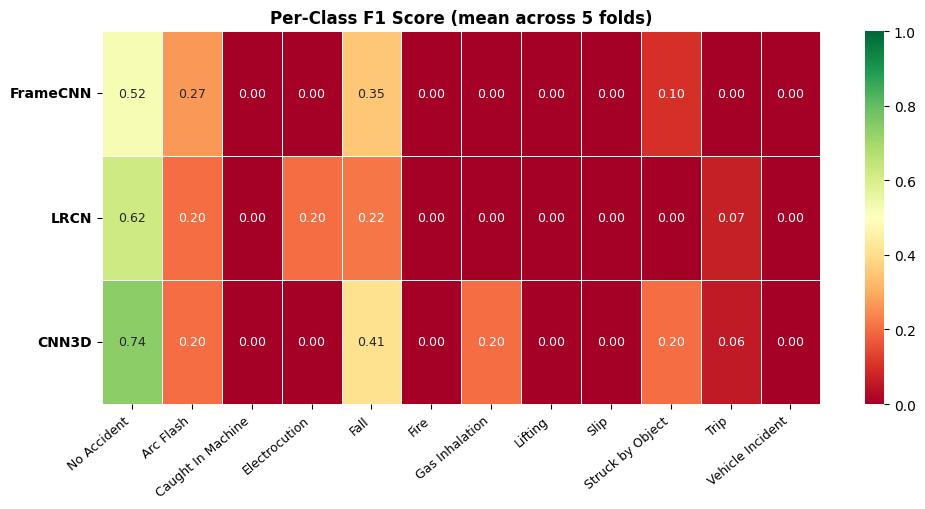

In [9]:
from visualize import plot_per_class_f1_heatmap

print("Running multiclass CV for per-class F1 analysis...")
fc_multi_results,    _ = run_cv("framecnn", multi_folds, MULTI_CLASSES, multi_weights, frame_cache=FRAME_CACHE)
lrcn_multi_results,  _ = run_cv("lrcn",     multi_folds, MULTI_CLASSES, multi_weights, frame_cache=FRAME_CACHE)
cnn3d_multi_results, _ = run_cv("cnn3d",    multi_folds, MULTI_CLASSES, multi_weights, n_frames=32, frame_cache=FRAME_CACHE)

fc_multi_summary    = summarise_cv(fc_multi_results,    MULTI_CLASSES)
lrcn_multi_summary  = summarise_cv(lrcn_multi_results,  MULTI_CLASSES)
cnn3d_multi_summary = summarise_cv(cnn3d_multi_results, MULTI_CLASSES)

f1_by_model = {
    "FrameCNN": fc_multi_summary["per_class_f1_mean"],
    "LRCN":     lrcn_multi_summary["per_class_f1_mean"],
    "CNN3D":    cnn3d_multi_summary["per_class_f1_mean"],
}

plot_per_class_f1_heatmap(
    f1_by_model, MULTI_CLASSES,
    os.path.join(OUTPUTS_DIR, "per_class_f1_heatmap.png")
)

---
## 8. Confusion Matrices

In [10]:
from evaluate import best_fold
from visualize import plot_confusion_matrix

for name, results in [("FrameCNN", fc_bin_results), ("LRCN", lrcn_bin_results), ("CNN3D", cnn3d_bin_results)]:
    bf = best_fold(results)
    plot_confusion_matrix(
        bf.confusion_mat, BINARY_CLASSES,
        title=f"{name} — Binary Confusion (Fold {bf.fold+1}, F1={bf.binary_f1:.3f})",
        out_path=os.path.join(OUTPUTS_DIR, f"confusion_{name.lower()}.png")
    )


Saved → /content/few_shot_outputs/confusion_framecnn.png
Saved → /content/few_shot_outputs/confusion_lrcn.png
Saved → /content/few_shot_outputs/confusion_cnn3d.png


---
## 9. Grad-CAM Temporal Attention

*Saliency maps for 3 misclassified clips from the best-performing model.*

In [11]:
import torch
from dataset import VideoDataset, get_transform
from models import build_model
from evaluate import best_fold
from visualize import plot_gradcam_temporal

best = best_fold(lrcn_bin_results)
fold_idx = best.fold
_, _, vl_p, vl_l = binary_folds[fold_idx]

wrong_idx = [i for i in range(len(best.preds))
             if best.preds[i] != best.labels[i]][:3]

model = build_model("lrcn", n_classes=len(BINARY_CLASSES))
ckpt  = os.path.join(OUTPUTS_DIR, f"lrcn_binary_fold{fold_idx+1}.pt")
model.load_state_dict(torch.load(ckpt, map_location=DEVICE), strict=False)
model = model.to(DEVICE).eval()

target_layer = model.backbone.conv_head  # last conv before pooling

transform_val = get_transform("val")
for idx in wrong_idx:
    vid_path = vl_p[idx]
    vid_id   = extract_base_vid(vid_path) or f"clip{idx}"
    true_lbl = BINARY_CLASSES[best.labels[idx]]
    pred_lbl = BINARY_CLASSES[best.preds[idx]]

    ds           = VideoDataset([vid_path], [0], N_FRAMES, transform_val, "lrcn")
    frame_tensor = ds[0][0].unsqueeze(0)  # [1, T, C, H, W]

    plot_gradcam_temporal(
        model, frame_tensor, target_layer,
        class_idx=best.preds[idx],
        class_name=f"Pred: {pred_lbl} | True: {true_lbl}",
        vid_id=vid_id,
        out_path=os.path.join(OUTPUTS_DIR, f"gradcam_{vid_id}.png"),
        model_type="lrcn",
    )

Saved → /content/few_shot_outputs/gradcam_VID031.png
Saved → /content/few_shot_outputs/gradcam_VID058.png


---
## 10. UMAP Embeddings

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /content/few_shot_outputs/umap_embeddings.png


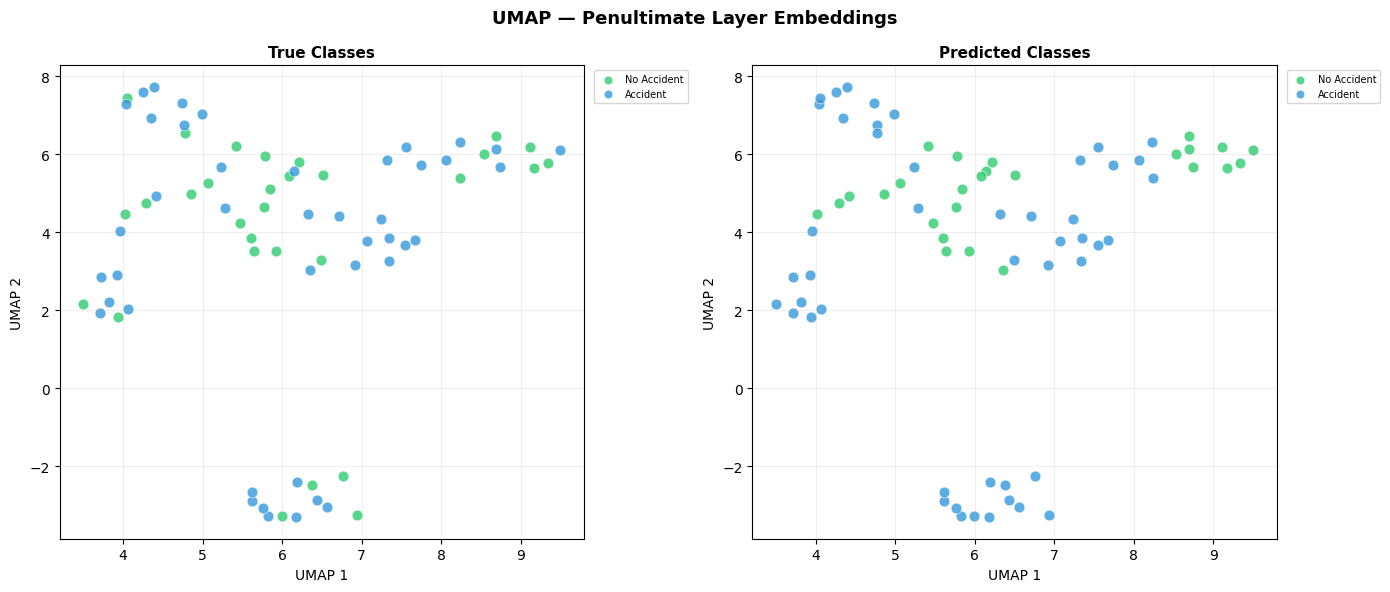

In [12]:
from visualize import plot_umap
from evaluate import best_fold
import numpy as np

# Aggregate all-fold embeddings for richest coverage
all_embs   = np.concatenate([r.embeddings for r in lrcn_bin_results if r.embeddings.size > 0])
all_true   = np.concatenate([r.labels     for r in lrcn_bin_results])
all_pred   = np.concatenate([r.preds      for r in lrcn_bin_results])

plot_umap(
    all_embs, all_true, all_pred, BINARY_CLASSES,
    out_path=os.path.join(OUTPUTS_DIR, "umap_embeddings.png")
)


---
## 11. Learning Curves

Saved → /content/few_shot_outputs/learning_curves.png


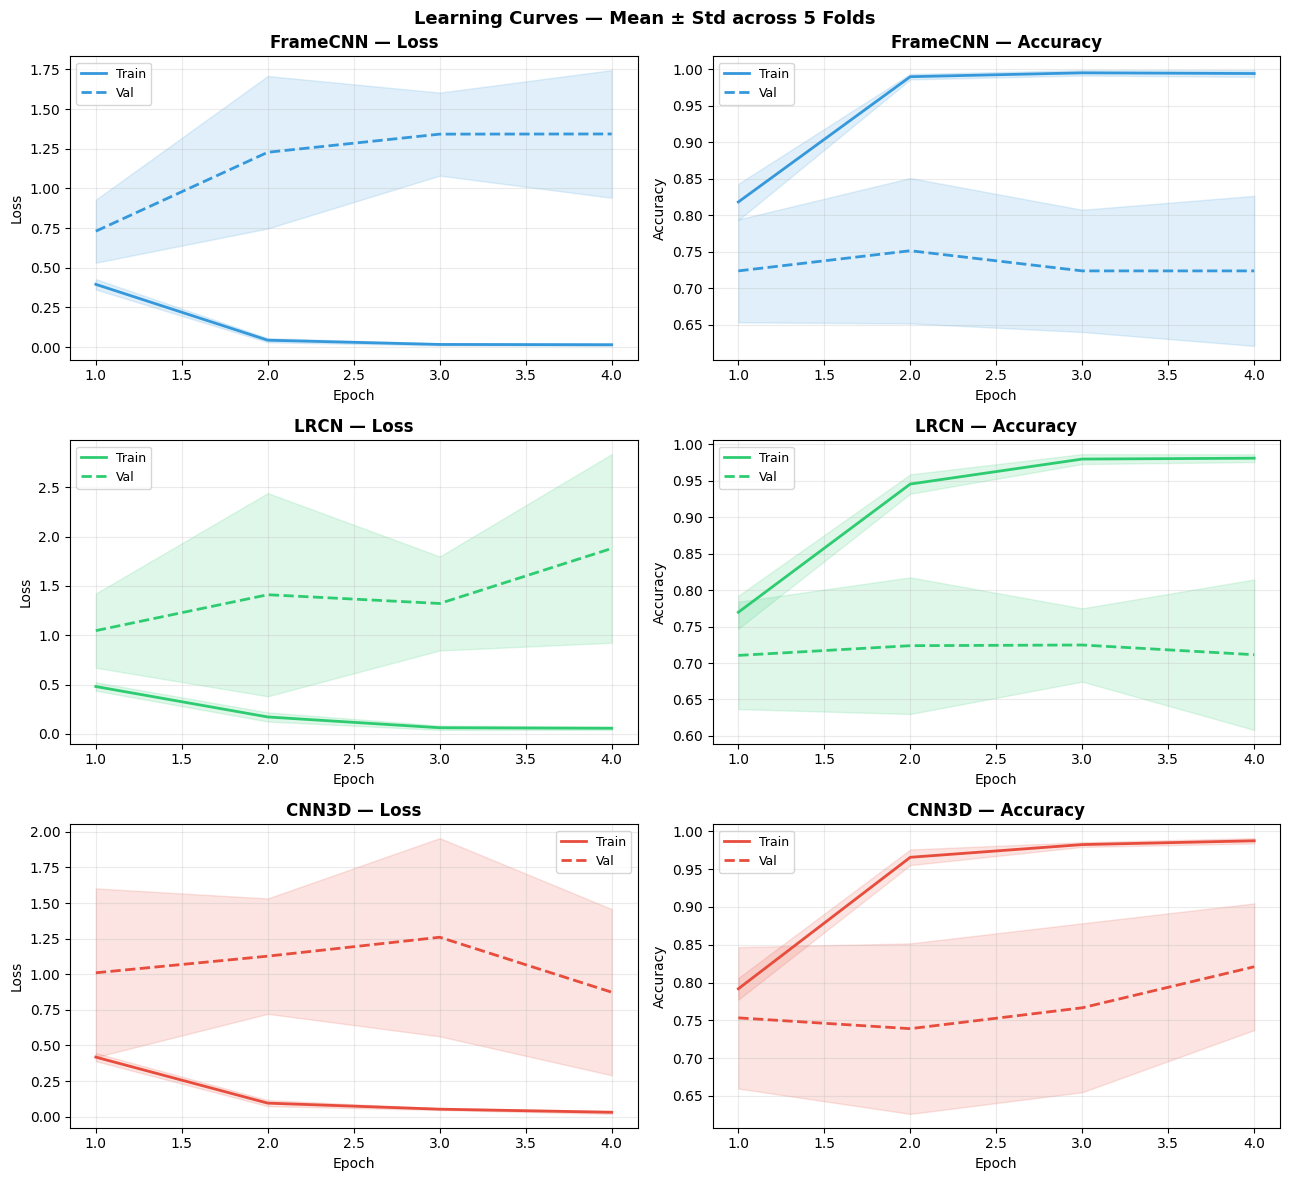

In [13]:
from visualize import plot_learning_curves

plot_learning_curves(
    {
        "FrameCNN": fc_bin_histories,
        "LRCN":     lrcn_bin_histories,
        "CNN3D":    cnn3d_bin_histories,
    },
    out_path=os.path.join(OUTPUTS_DIR, "learning_curves.png")
)


---
## Save Outputs to Drive

In [14]:
# ── Save all outputs to Drive ───────────────────────────────────────────────────────────────────
import shutil, os

DRIVE_OUTPUTS = f"{DRIVE_ROOT}/few_shot_outputs"
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

saved = []
for fname in sorted(os.listdir(OUTPUTS_DIR)):
    if fname.endswith((".png", ".csv", ".pt")):
        shutil.copy(os.path.join(OUTPUTS_DIR, fname),
                    os.path.join(DRIVE_OUTPUTS, fname))
        saved.append(fname)

print(f"Saved {len(saved)} files to Drive:")
for f in saved:
    print(f"  {f}")

Saved 41 files to Drive:
  class_distribution.png
  cnn3d_binary_fold1.pt
  cnn3d_binary_fold2.pt
  cnn3d_binary_fold3.pt
  cnn3d_binary_fold4.pt
  cnn3d_binary_fold5.pt
  cnn3d_multi_fold1.pt
  cnn3d_multi_fold2.pt
  cnn3d_multi_fold3.pt
  cnn3d_multi_fold4.pt
  cnn3d_multi_fold5.pt
  confusion_cnn3d.png
  confusion_framecnn.png
  confusion_lrcn.png
  framecnn_binary_fold1.pt
  framecnn_binary_fold2.pt
  framecnn_binary_fold3.pt
  framecnn_binary_fold4.pt
  framecnn_binary_fold5.pt
  framecnn_multi_fold1.pt
  framecnn_multi_fold2.pt
  framecnn_multi_fold3.pt
  framecnn_multi_fold4.pt
  framecnn_multi_fold5.pt
  gradcam_VID031.png
  gradcam_VID058.png
  learning_curves.png
  lrcn_binary_fold1.pt
  lrcn_binary_fold2.pt
  lrcn_binary_fold3.pt
  lrcn_binary_fold4.pt
  lrcn_binary_fold5.pt
  lrcn_multi_fold1.pt
  lrcn_multi_fold2.pt
  lrcn_multi_fold3.pt
  lrcn_multi_fold4.pt
  lrcn_multi_fold5.pt
  per_class_f1_heatmap.png
  results_summary.csv
  results_summary.png
  umap_embeddings.png


---
## 12. Frame Ablation

*Binary F1 vs number of frames sampled per clip. Answers: how much temporal context is needed before accuracy plateaus?*

In [15]:
# from visualize import plot_frame_ablation

# N_FRAMES_ABLATION = [4, 8, 16, 32]
# acc_by_model_and_n = {name: {} for name in ["FrameCNN", "LRCN", "CNN3D"]}

# for n_frames in N_FRAMES_ABLATION:
#     print(f"\n── n_frames={n_frames} ──")
#     for model_name, display_name in [("framecnn", "FrameCNN"), ("lrcn", "LRCN"), ("cnn3d", "CNN3D")]:
#         results, _ = run_cv(model_name, binary_folds, BINARY_CLASSES, bin_weights, n_frames=n_frames)
#         f1s = [r.binary_f1 for r in results]
#         acc_by_model_and_n[display_name][n_frames] = f1s
#         print(f"  {display_name:<10} Binary F1 = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

# plot_frame_ablation(
#     acc_by_model_and_n,
#     out_path=os.path.join(OUTPUTS_DIR, "frame_ablation.png")
# )
